---
---
# 1. Importaciones


In [1]:
globals().clear()#Limpia las variables

import numpy as np
from scipy.integrate import quad
from scipy.integrate import simpson
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

---
---
# 2. Definición de Funciones


## `f_int_mat`

### Entrada:
- `M_to_int`: Matriz que representa los valores de la función a integrar, que depende de las variables $\phi$ y $\theta$.
- `phi`: Valores sobre los cuales se evalúa la función respecto a la primera integración (en la dirección de $\phi$).
- `theta`: Valores sobre los cuales se evalúa la función respecto a la segunda integración (en la dirección de $\theta$).

### Proceso:
1. **Primera integración**: Se aplica la regla de Simpson a la dimensión correspondiente a $\theta$, aproximando la integral como:
   
   $
   I_{\theta} = \int_{c}^{d} f(\phi, \theta) \, d\theta \approx \sum w_i f(\phi, \theta_i)
   $
   
   donde los $w_i$ son los pesos asociados con la regla de Simpson y los $\theta_i$ son los puntos de evaluación.

2. **Segunda integración**: Se aplica la regla de Simpson a la dimensión correspondiente a $\phi$, integrando los resultados de la primera integración:
   
   $
   I = \int_{a}^{b} I_{\theta} \, d\phi \approx \sum w_j I_{\theta_j}
   $
   
   donde $w_j$ son los pesos correspondientes a la integración sobre $\phi$ y $I_{\theta_j}$ son los resultados de la integración sobre $\theta$.

   El argumento **axis=-1** en la función de Simpson indica que la integración se realiza sobre la última dimensión del array, que corresponde a $\theta$.

### Salida:
- **I**: Resultado de la integración doble aproximada sobre las dos dimensiones $\phi$ y $\theta$, utilizando la regla de Simpson para cada dimensión.


In [2]:
def f_int_mat(M_to_int, phi, theta):
        return simpson(simpson(M_to_int, theta, axis=-1), phi, axis=-1)


---


## `f_isotropic`


### Entrada
- `Ey`: Módulo de Young $E_y$, que representa la rigidez del material en dirección axial.
- `mu`: Coeficiente de Poisson $\nu$, que relaciona la deformación lateral con la deformación axial.

### Proceso
1. **Cálculo del módulo de corte** $G$: Este módulo representa la resistencia del material al esfuerzo cortante.

   $
   G = \frac{E_y}{2(1 + \nu)}
   $

2. **Inicialización de la matriz de flexibilidad** $S$ (6x6), que contiene las flexibilidades del material.

3. **Asignación de los valores de la matriz $S$:** La matriz $S$ tiene la siguiente forma:

   $
   S = \begin{bmatrix}
   \frac{1}{E_y} & -\frac{\nu}{E_y} & -\frac{\nu}{E_y} & 0 & 0 & 0 \\
   -\frac{\nu}{E_y} & \frac{1}{E_y} & -\frac{\nu}{E_y} & 0 & 0 & 0 \\
   -\frac{\nu}{E_y} & -\frac{\nu}{E_y} & \frac{1}{E_y} & 0 & 0 & 0 \\
   0 & 0 & 0 & \frac{1}{G} & 0 & 0 \\
   0 & 0 & 0 & 0 & \frac{1}{G} & 0 \\
   0 & 0 & 0 & 0 & 0 & \frac{1}{G}
   \end{bmatrix}
   $

4. **Cálculo del tensor constitutivo** $C$: Se obtiene invirtiendo la matriz de flexibilidad

   $
   C = S^{-1}
   $

### Salida
La función devuelve la matriz constitutiva **$C$**, utilizada en la mecánica de materiales para describir el comportamiento elástico de un sólido isotrópico.

>**Nota: no confundir esta matriz S de flexibilidad con la matriz de Eshelby S**



In [3]:
def f_isotropic(Ey, mu):
    # Cálculo del módulo de corte (G) a partir de Ey y Poisson
    G = Ey / (2 * (1 + mu)) #en teoria esto se calculó antes por lo que podría indicarse como variable de entrada pero ya está así
    
    # Inicialización de la matriz de flexibilidad S (6x6)
    S = np.zeros((6, 6))
    
    # Asignación de los elementos de la matriz S relacionados con el módulo de Young
    S[0, 0] = 1 / Ey  # Componente S11
    S[1, 1] = 1 / Ey  # Componente S22
    S[2, 2] = 1 / Ey  # Componente S33
    
    # Asignación de los elementos de la matriz S relacionados con el módulo de corte
    S[3, 3] = 1 / G   # Componente S44
    S[4, 4] = 1 / G   # Componente S55
    S[5, 5] = 1 / G   # Componente S66
    
    # Asignación de los elementos de la matriz S que representan los efectos de Poisson
    S[0, 1] = -mu / Ey  # Componente S12
    S[0, 2] = S[0, 1]  # Componente S13
    S[1, 2] = S[0, 1]  # Componente S23
    S[1, 0] = S[0, 1]  # Componente S21
    S[2, 0] = S[0, 2]  # Componente S31
    S[2, 1] = S[1, 2]  # Componente S32
    
    # Cálculo del tensor constitutivo C como la inversa de la matriz de flexibilidad S
    C = np.linalg.inv(S)  
    
    return C


## `f_eshelby_int` & `f_computeEshelbyIntegrals(a)`


### Entrada
- `a`: Un vector de semiejes principales $a = [a_1, a_2, a_3]$ que define la geometría de la inclusión elipsoidal.
- `nu`: Coeficiente de Poisson que caracteriza las propiedades del material.

### Proceso
1. **Cálculo de las integrales de Eshelby**:
   - Se calculan las integrales $A_i$ y $B_{ij}$ mediante integración numérica:
   
   $
   A_i = \int_0^\infty \frac{ds}{(a_i^2 + s) D(s)}
   $

   $
   B_{ij} = \int_0^\infty \frac{ds}{(a_i^2 + s)(a_j^2 + s) D(s)}
   $

   donde $D(s) = \sqrt{(a_1^2 + s)(a_2^2 + s)(a_3^2 + s)}$.

2. **Cálculo del tensor de Eshelby** $S_{ijkl}$:
   - El tensor se calcula como una función de las integrales anteriores y el coeficiente de Poisson $\nu$:

   $
   S_{ijkl} = f(A_i, B_{ij}, \nu)
   $

3. **Conversión de índices**:
   - El tensor de Eshelby tiene 81 componentes en 3D, pero debido a las simetrías del problema, se reduce utilizando la notación de Voigt a una matriz de $6 \times 6$:

   $
   S_{\alpha\beta} = \begin{bmatrix}
   S_{1111} & S_{1122} & S_{1133} & S_{1123} & S_{1113} & S_{1112} \\
   S_{2211} & S_{2222} & S_{2233} & S_{2223} & S_{2213} & S_{2212} \\
   S_{3311} & S_{3322} & S_{3333} & S_{3323} & S_{3313} & S_{3312} \\
   S_{2311} & S_{2322} & S_{2333} & S_{2323} & S_{2313} & S_{2312} \\
   S_{1311} & S_{1322} & S_{1333} & S_{1323} & S_{1313} & S_{1312} \\
   S_{1211} & S_{1222} & S_{1233} & S_{1223} & S_{1213} & S_{1212}
   \end{bmatrix}
   $

4. **Regla de conversión de índices**:

   $
   \begin{aligned}
     1 &\rightarrow 11, \quad 2 \rightarrow 22, \quad 3 \rightarrow 33, \\
     4 &\rightarrow 23, \quad 5 \rightarrow 13, \quad 6 \rightarrow 12.
   \end{aligned}
   $

### Salida
La función devuelve el **tensor de Eshelby** $S_{ijkl}$, reducido a una matriz $6 \times 6$ utilizando la notación de Voigt, que describe cómo la inclusión elipsoidal modifica la deformación interna respecto a la deformación aplicada externamente.

>**Fuente:** [Mura, T. (1987). *Micromechanics of Defects in Solids* (pp. 74–84). Springer Netherlands](http://link.springer.com/10.1007/978-94-009-3489-4)




In [ ]:
def f_compute_eshelby_integrals(a):

    def FD(s): return np.sqrt((a[0]**2 + s) * (a[1]**2 + s) * (a[2]**2 + s))
    
    def F(i, s): return 1 / ((a[i]**2 + s) * FD(s))
    
    def Fij(i, j, s): return 1 / ((a[i]**2 + s) * (a[j]**2 + s) * FD(s))
    
    c = 2 * np.pi * np.prod(a)
    
    A = np.zeros(3)
    A[0] = c * quad(lambda s: F(0, s), 0, np.inf)[0]
    A[1] = c * quad(lambda s: F(1, s), 0, np.inf)[0]
    A[2] = 4 * np.pi - A[0] - A[1]  # A(3) por complementariedad
    
    B = np.zeros((3, 3))
    idx_pairs = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]
    for i, j in idx_pairs:
        B[i, j] = c * quad(lambda s: Fij(i, j, s), 0, np.inf)[0]
        if i != j:
            B[j, i] = B[i, j]  # Simetría
    
    return A, B



In [5]:
def f_eshelby_int(a, nu):

    A, B = f_compute_eshelby_integrals(a)
    
    a2 = np.array(a)**2  # Cuadrados de las razones de aspecto
    c_offd = 1 / (8 * np.pi * (1 - nu))
    c_diag = 3 * c_offd
    c_maj = (1 - 2 * nu) * c_offd
    S = np.zeros((6, 6))
    
    # Componentes diagonales
    for i in range(3):
        S[i, i] = c_maj * A[i] + c_diag * a2[i] * B[i, i]
    
    # Componentes fuera de la diagonal
    idx_pairs = [(0, 1), (0, 2), (1, 2)]
    for i, j in idx_pairs:
        S[i, j] = -c_maj * A[i] + c_offd * a2[j] * B[i, j]
        S[j, i] = S[i, j]  # Simetría
    
    # Componentes de corte (4,4), (5,5), (6,6)
    c_offd_half = c_offd / 2
    c_maj_half = c_maj / 2
    S[3, 3] = (a2[1] + a2[2]) * B[1, 2] * c_offd_half + c_maj_half * (A[1] + A[2])
    S[4, 4] = (a2[0] + a2[2]) * B[0, 2] * c_offd_half + c_maj_half * (A[0] + A[2])
    S[5, 5] = (a2[0] + a2[1]) * B[0, 1] * c_offd_half + c_maj_half * (A[0] + A[1])
    
    # Ajustar términos de corte
    S[3:6, :] *= 2
    
    return S


## `f_compute_engineering_constants_sqrt2`


### Entrada
- **C**: Tensor de rigidez $C$ de dimensión $6 \times 6$, que representa las propiedades elásticas del material.

### Proceso
1. **Cálculo de la matriz de flexibilidad**:
   - La matriz de flexibilidad $S$ se obtiene tomando la inversa del tensor de rigidez $C$:

   $$
   S = C^{-1}
   $$

   Esta matriz $S$ describe cómo las deformaciones se inducen por tensiones aplicadas en diferentes direcciones.

2. **Cálculo de los módulos de elasticidad**:
   - Los módulos de elasticidad $E_i$ en cada dirección principal se calculan a partir de la diagonal de la matriz de flexibilidad $S$:

   $$
   E_i = \frac{1}{S_{ii}}, \quad i = 1, 2, 3, 4, 5, 6
   $$

   Esto proporciona los valores de rigidez del material en cada dirección principal.

3. **Cálculo de los coeficientes de Poisson**:
   - Los coeficientes de Poisson $\nu_{ij}$ se calculan como la relación entre la deformación en una dirección debido a una carga aplicada en otra dirección:

   $$
   \nu_{ij} = - E_i S_{ij}, \quad i \neq j
   $$

   Esto determina cómo una tensión en una dirección afecta las deformaciones en otras direcciones.

### Salida
La función devuelve los **módulos de elasticidad** $E_i$ y los **coeficientes de Poisson** $\nu_{ij}$ calculados a partir de la matriz de flexibilidad $S$. Estos valores son esenciales para analizar la respuesta elástica de un material ante tensiones aplicadas.




In [6]:
def f_compute_engineering_constants_sqrt2(C):
    E = np.zeros(6)
    nu = np.zeros(6)
    
    if np.linalg.matrix_rank(C) < 6:
        return E, nu
    
    # Compute compliance matrix:
    S = np.linalg.inv(C)  # Inverse of a symmetric matrix is symmetric
    
    for i in range(6):
        E[i] = 1 / S[i, i]
    
    # Define nu: [nu_23, nu_13, nu_12, nu_32, nu_31, nu_21]
    # Better accuracy for larger Poisson ratio:
    nuscale = -np.diag(E[:3]) @ S[:3, :3].T
    
    nu[0] = nuscale[1, 2]
    nu[1] = nuscale[0, 2]
    nu[2] = nuscale[0, 1]
    nu[3] = nuscale[2, 1]
    nu[4] = nuscale[2, 0]
    nu[5] = nuscale[1, 0]
    
    return E, nu

## `f_rottensor`


### Entrada
- **$\beta, \alpha, \psi$**: Ángulos de Euler (rad) que definen la rotación secuencial en los ejes 1, 2 y 3.
- **$A$**: Tensor original (rigidez, conformidad, tensiones o deformaciones) en coordenadas no rotadas.

### Proceso
1. **Construcción de las rotaciones elementales**  
   Se definen  
   $R_1 = \begin{bmatrix}
   1 & 0 & 0 \\[6pt]
   0 & \cos\beta & \sin\beta \\[6pt]
   0 & -\sin\beta & \cos\beta
   \end{bmatrix},\quad
   R_2 = \begin{bmatrix}
   \cos\alpha & 0 & -\sin\alpha \\[6pt]
   0 & 1 & 0 \\[6pt]
   \sin\alpha & 0 & \cos\alpha
   \end{bmatrix},\quad
   R_3 = \begin{bmatrix}
   \cos\psi & \sin\psi & 0 \\[6pt]
   -\sin\psi & \cos\psi & 0 \\[6pt]
   0 & 0 & 1
   \end{bmatrix}.$  
   Se obtiene la rotación global  
   $w = R_3\,R_2\,R_1.$

2. **Formación de las matrices $K_i$**  
   Se calculan los productos cuadráticos y cruzados de los componentes $w_{ij}$: 
    
   $K_1 = [w_{ij}^2]_{3\times3},\quad
   K_2 = [w_{i,j+1}\,w_{i,j+2}]_{3\times3},\quad
   K_3 = [w_{j+1,i}\,w_{j+2,i}]_{3\times3},$  

   $K_4 = \begin{bmatrix}
   w_{22}w_{33}+w_{23}w_{32} & w_{23}w_{31}+w_{21}w_{33} & w_{21}w_{32}+w_{22}w_{31} \\[4pt]
   w_{32}w_{13}+w_{33}w_{12} & w_{33}w_{11}+w_{31}w_{13} & w_{31}w_{12}+w_{32}w_{11} \\[4pt]
   w_{12}w_{23}+w_{13}w_{22} & w_{13}w_{21}+w_{11}w_{23} & w_{11}w_{22}+w_{12}w_{21}
   \end{bmatrix}.$

3. **Ensamblaje de las transformaciones**  
   Para tensiones:  
   $
   g_{\text{change3D1}} = \begin{bmatrix}
   K_1 & 2\,K_2 \\[4pt]
   K_3 & K_4
   \end{bmatrix}.
   $ 

   Para deformaciones:  
   $
   g_{\text{change3D2}} = \begin{bmatrix}
   K_1 & K_2 \\[4pt]
   2\,K_3 & K_4
   \end{bmatrix}.
   $

4. **Rotación del tensor**  
   Dependiendo del tipo de tensor $A$, se aplica la fórmula correspondiente:  
   - Rigidez: $A_{\rm rot}=(T_2^{-1})^T\,A\,T_1^T$  
   - Conformidad: $A_{\rm rot}=(T_1^{-1})^T\,A\,T_2^T$  
   - Eshelby:   $A_{\rm rot}=T_2\,A\,T_2^{-1}$  
   - Tensiones: $A_{\rm rot}=T_1\,A\,T_1^{-1}$  

### Salida
La función devuelve el tensor $A_{\rm rot}$ rotado y las matrices de transformación `gchange3D1` y `gchange3D2`, que permiten expresar tensiones y deformaciones en el sistema de coordenadas rotado.



In [7]:
def f_rottensor(Beta, Alpha, Psi, order, A, val):
    # Matrices W y invW
    W = np.diag([1, 1, 1, 2, 2, 2])
    invW = np.diag([1, 1, 1, 0.5, 0.5, 0.5])
    
    # Obtener matrices de rotación
    T1, T2 = rotmatrix(Beta, Alpha, Psi, order)
    
    # Cálculo del tensor rotado
    if val == 1:  # Tensor de rigidez
        A_rot = np.linalg.inv(T2.T) @ A @ T1.T
    elif val == 2:  # Tensor de cumplimiento
        A_rot = np.linalg.inv(T1.T) @ A @ T2.T
    elif val == 3:  # Tensor de Eshelby
        A_rot = T2 @ A @ np.linalg.inv(T2)
    elif val == 4:  # Tensor B
        A_rot = T1 @ A @ np.linalg.inv(T1)
    else:
        raise ValueError("El valor de 'val' debe estar entre 1 y 4")
    
    return A_rot

def rotmatrix(Beta, Alpha, Psi, order):
    # Convertir a grados
    Beta = np.degrees(Beta)
    Alpha = np.degrees(Alpha)
    Psi = np.degrees(Psi)
    
    # Matrices de rotación
    R = np.zeros((3, 3, 3))
    R[0] = np.array([[1, 0, 0], [0, np.cos(np.radians(Beta)), np.sin(np.radians(Beta))],
                      [0, -np.sin(np.radians(Beta)), np.cos(np.radians(Beta))]])
    R[1] = np.array([[np.cos(np.radians(Alpha)), 0, -np.sin(np.radians(Alpha))], [0, 1, 0],
                      [np.sin(np.radians(Alpha)), 0, np.cos(np.radians(Alpha))]])
    R[2] = np.array([[np.cos(np.radians(Psi)), np.sin(np.radians(Psi)), 0],
                      [-np.sin(np.radians(Psi)), np.cos(np.radians(Psi)), 0], [0, 0, 1]])
    
    # Calcular matriz de rotación final
    w = R[order[2] - 1] @ R[order[1] - 1] @ R[order[0] - 1]
    
    # Construcción de matrices K1, K2, K3, K4
    K1 = w**2
    K2 = np.array([[w[0,1]*w[0,2], w[0,2]*w[0,0], w[0,0]*w[0,1]],
                    [w[1,1]*w[1,2], w[1,2]*w[1,0], w[1,0]*w[1,1]],
                    [w[2,1]*w[2,2], w[2,2]*w[2,0], w[2,0]*w[2,1]]])
    K3 = np.array([[w[1,0]*w[2,0], w[1,1]*w[2,1], w[1,2]*w[2,2]],
                    [w[2,0]*w[0,0], w[2,1]*w[0,1], w[2,2]*w[0,2]],
                    [w[0,0]*w[1,0], w[0,1]*w[1,1], w[0,2]*w[1,2]]])
    K4 = np.array([[w[1,1]*w[2,2] + w[1,2]*w[2,1], w[1,2]*w[2,0] + w[1,0]*w[2,2], w[1,0]*w[2,1] + w[1,1]*w[2,0]],
                    [w[2,1]*w[0,2] + w[2,2]*w[0,1], w[2,2]*w[0,0] + w[2,0]*w[0,2], w[2,0]*w[0,1] + w[2,1]*w[0,0]],
                    [w[0,1]*w[1,2] + w[0,2]*w[1,1], w[0,2]*w[1,0] + w[0,0]*w[1,2], w[0,0]*w[1,1] + w[0,1]*w[1,0]]])
    
    # Matrices de transformación
    gchange3D1 = np.block([[K1, 2 * K2], [K3, K4]])  # Tensiones
    gchange3D2 = np.block([[K1, K2], [2 * K3, K4]])  # Deformaciones
    
    return gchange3D1, gchange3D2


## `f_orientational_average`



### Entrada
- `number_theta`: Número de pasos en la discretización del ángulo $\theta$.
- `number_phi`: Número de pasos en la discretización del ángulo $\phi$.
- `theta_max`: Valor máximo del ángulo $\theta$.
- `phi_max`: Valor máximo del ángulo $\phi$.
- `A`: Tensor de entrada que se desea promediar.
- `k`: Parámetro de la ODF que controla el grado de alineación de las inclusiones.
- `val`: Relación de rotación específica para el tipo de tensor.

### Proceso
1. **Definición de las mallas de integración**  
   Se generan los vectores  
   $  
   \theta = \{0, \Delta\theta, 2\Delta\theta, \dots, \theta_{\max}\},\quad  
   \phi = \{0, \Delta\phi, 2\Delta\phi, \dots, \phi_{\max}\},  
   $  
   con  
   $  
   \Delta\theta = \frac{\theta_{\max}}{\texttt{number\_theta}},\quad  
   \Delta\phi = \frac{\phi_{\max}}{\texttt{number\_phi}}.  
   $

2. **Evaluación de la ODF**  
   Se calcula la función de distribución de orientaciones:  
   - Uniforme:  
     $  
     \mathrm{ODF}(\theta) = 1  
     $  
   - Alineación parcial:  
     $  
     \mathrm{ODF}(\theta) = \exp\bigl(-k\,\theta^2\bigr)  
     $

3. **Rotación del tensor**  
   Para cada par $(\theta_i,\phi_j)$ se obtiene el tensor rotado  
   $  
   A(\theta_i,\phi_j) = R(\theta_i,\phi_j)\,A\,R^T(\theta_i,\phi_j)  
   $  
   usando la función `f_rottensor`.

4. **Integración numérica**  
   Se calcula la integral ponderada del tensor y la del denominador:  
   $  
   N = \int_0^{\phi_{\max}}\!\!\int_0^{\theta_{\max}}  
     A(\theta,\phi)\,\mathrm{ODF}(\theta)\,\sin\theta  
     \,d\theta\,d\phi,  
   $  
   $  
   D = \int_0^{\phi_{\max}}\!\!\int_0^{\theta_{\max}}  
     \mathrm{ODF}(\theta)\,\sin\theta  
     \,d\theta\,d\phi,  
   $  
   donde ambas integrales se aproximan con la función `int_mat`.

5. **Cálculo del promedio**  
   Se obtiene el tensor promedio:  
   $  
   A_{\mathrm{med}}  
   = \frac{N}{D}.  
   $

### Salida
- `A_med`: Tensor orientacionalmente promediado, de la misma dimensión que $A$, que representa la respuesta efectiva del material bajo la distribución de orientaciones dada.



In [8]:
def f_orientational_average(number_theta, number_phi, theta_max, phi_max, A, k, val):
    """
    Compute orientational average of tensor A.

    Parameters:
    number_theta : int
        Number of steps of integration for the variable theta.
    number_phi : int
        Number of steps of integration for the variable phi.
    theta_max : float
        Maximum value for variable theta.
    phi_max : float
        Maximum value for variable phi.
    A : numpy.ndarray
        Tensor to be averaged.
    k : float
        Parameter of the ODF according to Odegard et al.
    val : any
        Additional parameter for rottensor function.

    Returns:
    numpy.ndarray
        Orientational average of input tensor A.
    """

    if k > 1_000_000:  # Perfectly aligned case
        return A

    theta = np.linspace(0, theta_max, number_theta + 1)
    phi = np.linspace(0, phi_max, number_phi + 1)

    # Orientation Distribution Function (ODF)
    caso = 3  # General case
    ODF = np.zeros_like(theta)

    if caso == 1:
        ODF[:] = 1  # Random orientation
    elif caso == 2:
        ODF[0] = 1  # Aligned
    else:
        ODF = np.exp(-k * theta**2)  # General case

    # Initialize matrices
    A_phi_theta = np.zeros((6, 6, len(phi), len(theta)))
    denom_phi_theta = np.zeros((1, 1, len(phi), len(theta)))
    A_to_int = np.zeros_like(A_phi_theta)

    for t, theta_loop in enumerate(theta):
        for s, phi_loop in enumerate(phi):
            A_phi_theta[:, :, s, t] = f_rottensor(theta_loop, phi_loop, 0, [3, 1, 2], A, val)
        
        denom_phi_theta[0, 0, :, t] = ODF[t] * np.sin(theta_loop)
        A_to_int[:, :, :, t] = A_phi_theta[:, :, :, t] * (ODF[t] * np.sin(theta_loop))

    # Perform double integration
    denom = f_int_mat(denom_phi_theta, phi, theta)
    Amed = f_int_mat(A_to_int, phi, theta) / denom

    return Amed


## `f_ellipsoidalinter_random`

La función `f_ellipsoidalinter_random` modela la homogeneización de un material compuesto con inclusiones elipsoidales mediante el método de Mori–Tanaka, considerando interacción entre matriz e inclusiones.

### Entrada
- `C_m`: Tensor de rigidez de la matriz.
- `C_P`: Tensor de rigidez de las inclusiones primarias.
- `C_I`: Tensor de rigidez de las inclusiones secundarias.
- `S_P`: Tensor de concentración de esfuerzo para inclusiones primarias.
- `S_I`: Tensor de concentración de esfuerzo para inclusiones secundarias.
- `v_P`: Fracción volumétrica de la fase primaria.
- `v_I`: Fracción volumétrica de la fase secundaria.
- `f_orientational_average`: Función para promediado orientacional de un tensor.

### Proceso
1. **Operadores de interacción**  
   $
   \psi_P = (C_P - C_m)\,C_m^{-1}
   $  
   $
   \psi_I = (C_I - C_m)\,C_m^{-1}
   $  
   $
   \Delta S = S_I - S_P
   $

2. **Cálculo de tensores de dilatación**  
   $
   M_P = -I\bigl(S_P + \psi_P + \Delta S\,(S_P + \psi_P - \tfrac{v_P}{v_I}\Delta S)^{-1}(S_P + \psi_I - \tfrac{v_P}{v_I}\Delta S)\bigr)^{-1}
   $  
   $
   M_I = -I\bigl(\Delta S + (S_P + \psi_P)(S_P + \psi_P - \tfrac{v_P}{v_I}\Delta S)^{-1}(S_P + \psi_I - \tfrac{v_P}{v_I}\Delta S)\bigr)^{-1}
   $

3. **Operadores de dilatación efectivos**  
   $
   A_{dil1} = I + S_P\,M_P + \Delta S\,M_I
   $  
   $
   A_{dil2} = I + S_I\,M_I + \tfrac{v_P}{v_I}\,\Delta S\,(M_P - M_I)
   $

4. **Términos de endurecimiento**  
   $
   B_{dil1} = C_P\,A_{dil1}\,C_m^{-1}
   $  
   $
   B_{dil2} = C_I\,A_{dil2}\,C_m^{-1}
   $

5. **Promediado orientacional**  

    $A_{med1} = \text{orientational\_average}(A_{dil1})$

    $A_{med2} = \text{orientational\_average}(A_{dil2})$

    $B_{med1} = \text{orientational\_average}(B_{dil1})$

    $B_{med2} = \text{orientational\_average}(B_{dil2})$


6. **Cálculo de la rigidez efectiva**  
   $
   C_{eff} = \bigl(v_m\,C_m + v_i\,B_{med2}\,C_m + v_p\,B_{med1}\,C_m\bigr)\,\bigl(v_m\,I + v_i\,A_{med2} + v_p\,A_{med1}\bigr)^{-1}
   $  
   donde $v_m = 1 - v_P - v_I$.

### Salida
- `C_eff`: Tensor de rigidez efectivo del material compuesto, que estima la respuesta elástica global.


In [9]:
def f_ellipsoidalinter_random(Cp, Ci, Cm, Si, Sp, vp, vi):
    # Parámetros de integración
    number_theta = 100
    number_phi = 100
    
    theta_max = np.pi / 2
    phi_max = 2 * np.pi
    
    if vp == 0:
        return Cm
    
    Id = np.eye(6)
    vm = 1 - vp - vi
    
    psiP = np.linalg.solve(Cp - Cm, Cm)
    psiI = np.linalg.solve(Ci - Cm, Cm)
    
    dS = Si - Sp
    
    Mp = -np.linalg.inv(Sp + psiP + dS @ np.linalg.inv(Sp + psiP - (vp / vi) * dS) @ (Sp + psiI - (vp / vi) * dS))
    Mi = -np.linalg.inv(dS + (Sp + psiP) @ np.linalg.inv(Sp + psiP - (vp / vi) * dS) @ (Sp + psiI - (vp / vi) * dS))
    
    Adil1 = Id + Sp @ Mp + dS @ Mi
    Adil2 = Id + Si @ Mi + (vp / vi) * dS @ (Mp - Mi)
    
    Bdil1 = Cp @ Adil1 @ np.linalg.inv(Cm)
    Bdil2 = Ci @ Adil2 @ np.linalg.inv(Cm)
    
    Amed1 = f_orientational_average(number_theta, number_phi, theta_max, phi_max, Adil1, 0, 3)
    Amed2 = f_orientational_average(number_theta, number_phi, theta_max, phi_max, Adil2, 0, 3)
    
    Bmed1 = f_orientational_average(number_theta, number_phi, theta_max, phi_max, Bdil1, 0, 4)
    Bmed2 = f_orientational_average(number_theta, number_phi, theta_max, phi_max, Bdil2, 0, 4)
    
    Ceff = (vm * Cm + vi * Bmed2 @ Cm + vp * Bmed1 @ Cm) @ np.linalg.inv(vm * Id + vi * Amed2 + vp * Amed1)
    
    return Ceff


## `f_ellipsoidal_nointer_random`


### Entrada
- `C_i`: Tensor de rigidez de las inclusiones, de dimensión $6\times6$.
- `C_m`: Tensor de rigidez de la matriz, de dimensión $6\times6$.
- `S_eby` : Tensor de Eshelby $S$, de concentración de esfuerzo para las inclusiones.
- `v_i`: Fracción volumétrica de las inclusiones.

### Proceso
1. Cálculo de la fracción volumétrica de la matriz  
   $
   v_m = 1 - v_i
   $

2. Definición de la malla de integración para el promedio orientacional  
   - Número de pasos en $\theta$: $\text{number\_theta}=20$  
   - Número de pasos en $\phi$: $\text{number\_phi}=20$  
   - Ángulo máximo polar: $\theta_{\max} = \pi/2$  
   - Ángulo máximo azimutal: $\phi_{\max} = 2\pi$

3. Cálculo de los tensores intermedios  
   - Tensor $A$:  
     $
     A = \bigl[I + S_{eby}\,C_m^{-1}\,(C_i - C_m)\bigr]^{-1}
     $  
   - Tensor $B$:  
     $
     B = C_i\,A\,C_m^{-1}
     $

4. Promedio orientacional  
   - Se obtiene el tensor promedio de $A$:  
     $
     A_{\mathrm{med}} = \text{orientational\_average}(A)
     $ 
   - Se obtiene el tensor promedio de $B$:  
     $
     B_{\mathrm{med}} = \text{orientational\_average}(B)
     $ 

5. Cálculo del tensor de rigidez efectivo  
   $
   C_{\mathrm{eff}}
   = \bigl(v_m\,C_m + v_i\,B_{\mathrm{med}}\,C_m\bigr)\,\bigl(v_m\,I + v_i\,A_{\mathrm{med}}\bigr)^{-1}
   $

### Salida
- `Ceff`: Tensor de rigidez efectivo del material compuesto, de dimensión $6\times6$, que representa la respuesta elástica macroscópica del conjunto matriz–inclusiones.


In [10]:

def f_ellipsoidal_nointer_random(Ci, Cm, Seby, vi):
    vm = 1 - vi
    
    number_theta = 20
    number_phi = 20
    
    theta_max = np.pi / 2
    phi_max = 2 * np.pi
    
    Id = np.eye(6)
    A = np.linalg.inv(Id + Seby @ np.linalg.inv(Cm) @ (Ci - Cm))
    B = Ci @ A @ np.linalg.inv(Cm)
    
    Amed = f_orientational_average(number_theta, number_phi, theta_max, phi_max, A, 0, 3)
    Bmed = f_orientational_average(number_theta, number_phi, theta_max, phi_max, B, 0, 4)
    
    Ceff = (vm * Cm + vi * Bmed @ Cm) @ np.linalg.inv(vm * Id + vi * Amed)
    
    return Ceff


## `f_MTinterparam`

La función `f_MTinterparam` calcula el módulo efectivo de un material compuesto con capa de interfase usando un modelo basado en Mori–Tanaka y promedios orientacionales.

### Entrada
- `t`: Espesor de la interfase (float).
- `E_i`: Módulo de Young de la interfase (float).
- `v_p`: Fracción volumétrica de partículas (array o float).
- `E_m`: Módulo de Young de la matriz (float).
- `mu_m`: Módulo de corte de la matriz (float).
- `E_p`: Módulo de Young de las partículas (float).
- `mu_p`: Módulo de corte de las partículas (float).
- `mu_i`: Módulo de corte de la interfase (float).
- `kappa`: Relación de aspecto de la interfase (float).
- `Deq`: Diámetro equivalente de las partículas (float).
- `typeinter`: Tipo de interfase (1 para “soft”, 2 para “hard”) (int).

### Proceso
1. **Conversión de fracción volumétrica**  
   Si `v_p` es escalar, se convierte a array para poder iterar.

2. **Cálculo de tensores isotrópicos**  
   Se obtienen los tensores de rigidez de cada fase:  
   $
   C_m = f_{\mathrm{isotropic}}(E_m,\mu_m),\quad
   C_p = f_{\mathrm{isotropic}}(E_p,\mu_p),\quad
   C_i = f_{\mathrm{isotropic}}(E_i,\mu_i).
   $

3. **Cálculo de tensores de Eshelby**  
   Para inclusiones primarias y de interfase:  
   $
   S_p = f_{\mathrm{eshelby\_int}}([1,\kappa,1],\mu_m),\quad
   S_i = f_{\mathrm{eshelby\_int}}([1,\kappa,1],\mu_m).
   $

4. **Relación de espesor a diámetro**  
   $
   \lambda = \frac{t}{D_{eq}}.
   $

5. **Determinación de volumen de interfase**  
   Para cada valor de $v_{p}$ se calcula $v_{i}$ usando:  
   - Soft: $v_{i}=f_{\mathrm{softinterphase}}(\kappa,\lambda,v_{p})$.  
   - Hard: $v_{i}=f_{\mathrm{hardinterphase}}(\kappa,\lambda,v_{p})$.

6. **Homogeneización**  
   Se obtiene el tensor de rigidez efectivo:
   $
   C_{\mathrm{eff}}
   = f_{\mathrm{ellipsoidalinter\_random}}(C_p,C_i,C_m,S_i,S_p,v_{p},v_{i}).
   $

7. **Cálculo de constantes de ingeniería**  
   A partir de $C_{\mathrm{eff}}$ se extraen:
   $
   (E,\nu) = f_{\mathrm{computeEngineeringConstantsSqrt2}}(C_{\mathrm{eff}}),
   $
   y se guarda $E_{\mathrm{eff}}=E_{1}$.

### Salida
- `Eeff`: Array con el módulo de Young efectivo ($E_{\mathrm{eff}}$) para cada fracción volumétrica de partículas.


In [11]:
# Definir las funciones auxiliares antes de usar esta función
# isotropic(), eshelby_int(), softinterphase(), hardinterphase(),
# ellipsoidalinter_random2(), computeEngineeringConstantsSqrt2()

def f_MTinterparam(t, E_i, vp, E_m, mu_m, E_p, mu_p, mu_i, Kappa, Deq, typeinter):
    """
    Calcula el módulo efectivo Eeff basado en el modelo de interfase.

    Parámetros:
    t : float -> Espesor de la interfase.
    Ei : float -> Módulo de la interfase.
    vp : array -> Fracción volumétrica de partículas.
    Em : float -> Módulo de la matriz.
    poism : float -> Coeficiente de Poisson de la matriz.
    Ep : float -> Módulo de las partículas.
    poisp : float -> Coeficiente de Poisson de las partículas.
    poisi : float -> Coeficiente de Poisson de la interfase.
    Kappa : float -> Relación de aspecto de la interfase.
    Deq : float -> Diámetro equivalente de las partículas.
    typeinter : int -> Tipo de interfase (1 -> Soft, 2 -> Hard).

    Retorna:
    Eeff : array -> Módulo efectivo calculado.
    """

    if np.isscalar(vp):  # Asegura que `vp` sea un array
        vp = np.array([vp])
        
    Cm = f_isotropic(E_m, mu_m)  # Propiedades de la matriz
    Cp = f_isotropic(E_p, mu_p)  # Propiedades de las partículas
    Ci = f_isotropic(E_i, mu_i)  # Propiedades de la interfase

    Sp = f_eshelby_int([1, Kappa, 1], mu_m)
    Si = f_eshelby_int([1, Kappa, 1], mu_m)

    lambda_ratio = t / Deq  # Relación de espesor con diámetro

    vicont = np.zeros(len(vp))
    Eeff = np.zeros(len(vp))

    for i, vp_i in enumerate(vp):
        if typeinter == 1:
            vicont[i] = f_softinterphase(Kappa, lambda_ratio, vp_i)
        else:
            vicont[i] = f_hardinterphase(Kappa, lambda_ratio, vp_i)

        vi = vicont[i]

        # Homogeneización
        Ceff = f_ellipsoidalinter_random(Cp, Ci, Cm, Si, Sp, vp_i, vi)
        E, nu = f_compute_engineering_constants_sqrt2(Ceff)

        Eeff[i] = E[0]

    return Eeff

## `f_softinterphase`

La función `f_softinterphase` calcula la fracción volumétrica efectiva de la interfase blanda ($v_i$) en un material compuesto con inclusiones elipsoidales, considerando su esfericidad y espesor.

### Entrada
- `kappa`: Relación de aspecto de la inclusión, $κ = a/b$.
- `lambda`: Relación entre el espesor de la interfase $t$ y el diámetro equivalente $D_{eq}$, $λ = t/D_{eq}$.
- `v_p`: Fracción volumétrica de partículas en el compuesto.

### Proceso
1. **Cálculo de $\eta$ y ángulo $\phi$**  
   $ η = \begin{cases}
   1/κ, & κ>1\ (\text{prolata})\\
   κ,   & κ\le1\ (\text{oblata o esfera})
   \end{cases}
   $,  
   $ \phi = \cos^{-1}(η). $

2. **Determinación de la esfericidad $n_κ$**  
   $ n_κ = \begin{cases}
   \dfrac{2\,κ^{2/3}\sin\phi}{\sin\phi + κ^2\,\operatorname{atanh}(\sin\phi)}, & κ<1\ (\text{oblata})\\[8pt]
   1, & κ=1\ (\text{esfera})\\[6pt]
   \dfrac{2\,κ^{2/3}\tan\phi}{\tan\phi + κ^2\,\phi}, & κ>1\ (\text{prolata})
   \end{cases}
   $

3. **Cálculo de $v_i$**  
   $$
   v_i = (1 - v_p)\left[1 - \exp\Bigl(-\tfrac{6\,v_p}{1 - v_p}\bigl(
     \tfrac{λ}{n_κ}
     + \bigl(2 + \tfrac{3\,v_p}{n_κ^2(1 - v_p)}\bigr)λ^2
     + \tfrac{4}{3}\bigl(1 + \tfrac{3\,v_p}{n_κ(1 - v_p)^2}
       + \tfrac{m\,v_p^2}{n_κ^3(1 - v_p)^2}\bigr)λ^3
   \bigr)\Bigr)\right].
   $$

   - El término $λ/n_κ$ captura el efecto lineal del espesor.
   - Los términos en $λ^2$ y $λ^3$ ajustan contribuciones no lineales según $v_p$.
   - El parámetro $m$ (0, 2 o 3) ajusta el modelo según experimentación.

### Salida
- `v_i`: Fracción volumétrica efectiva de la interfase blanda, que crece con $v_p$ y depende de la geometría y espesor de la capa interfacial.


In [12]:
def f_softinterphase(Kappa, Lambda, vp):
    """
    Calculate the effective volume fraction of the soft interphase.

    Parameters:
    Kappa (float): Aspect ratio of particles.
    Lambda (float): Geometric size factor t/Deq.
    vp (float): Volume fraction of particles.

    Returns:
    float: Effective volume fraction of the interphase.
    """
    # Compute eta based on Kappa
    eta = 1 / Kappa if Kappa > 1 else Kappa

    # Compute phi
    phi = np.arccos(eta)

    # Compute nkappa based on Kappa
    if Kappa < 1:
        nkappa = (2 * Kappa ** (2/3) * np.sin(phi)) / (np.sin(phi) + Kappa**2 * np.arctanh(np.sin(phi)))
    elif Kappa == 1:
        nkappa = 1
    else:
        nkappa = (2 * Kappa ** (2/3) * np.tan(phi)) / (np.tan(phi) + Kappa**2 * phi)

    # m can be 0, 2, or 3
    m = 0

    # Compute vi
    vi = (1 - vp) * (1 - np.exp(-(6 * vp / (1 - vp)) * 
                                 (Lambda / nkappa + 
                                  (2 + 3 * vp / (nkappa**2 * (1 - vp))) * Lambda**2 + 
                                  (4 / 3) * (1 + 3 * vp / (nkappa * (1 - vp)**2) + 
                                             m * vp**2 / (nkappa**3 * (1 - vp)**2)) * Lambda**3)))
    
    return vi

## `f_hardinterphase`

La función `f_hardinterphase` calcula la fracción volumétrica efectiva de la interfase rígida ($v_i$) en un material compuesto con inclusiones elipsoidales duras, considerando su esfericidad y aspecto geométrico.

### Entrada
- `kappa` (Kappa): Relación de aspecto de la inclusión, $\kappa = a/b$.
- `lambda` (Lambda): Relación entre el espesor de la interfase $t$ y el diámetro equivalente $D_{eq}$, $\lambda = t/D_{eq}$.
- `v_p`: Fracción volumétrica de partículas en el compuesto.

### Proceso
1. **Cálculo de $\eta$ y ángulo $\phi$**  
   $  
   \eta = \begin{cases}
     1/\kappa, & \kappa>1\ (\text{prolata})\\
     \kappa,   & \kappa\le1\ (\text{oblata o esfera})
   \end{cases},\quad
   \phi = \arccos(\eta).
   $

2. **Determinación de la esfericidad $n_{\kappa}$**  
   $  
   n_{\kappa} = \begin{cases}
   \dfrac{2\,\kappa^{2/3}\,\sin\phi}{\sin\phi + \kappa^2\,\operatorname{atanh}(\sin\phi)}, & \kappa<1\\[8pt]
   1, & \kappa=1\\[6pt]
   \dfrac{2\,\kappa^{2/3}\,\tan\phi}{\tan\phi + \kappa^2\,\phi}, & \kappa>1
   \end{cases}
   $

3. **Cálculo del parámetro $\omega$**  
   $  
   \omega = \begin{cases}
   \kappa^{2/3} + \dfrac{\arcsin\bigl(\sqrt{1-\kappa^2}\bigr)}{\kappa^{1/3}\sqrt{1-\kappa^2}}, & \kappa\le1\\[8pt]
   \kappa^{2/3} + \dfrac{\ln\bigl(\kappa + \sqrt{\kappa^2-1}\bigr)}{\kappa^{1/3}\sqrt{\kappa^2-1}}, & \kappa>1
   \end{cases}
   $

4. **Cálculo de la fracción de interfase $v_i$**  
   - Para esfera perfecta ($\kappa=1$):  
     $  
     v_i = v_p\bigl[(1 + 2\lambda)^3 - 1\bigr].
     $  
   - Para elipsoides ($\kappa\neq1$):  
     $  
     v_i = 6\,v_p\Bigl(\tfrac{\lambda}{n_{\kappa}} + \omega\,\lambda^2 + \tfrac{4}{3}\,\lambda^3\Bigr).
     $

### Salida
- `v_i`: Fracción volumétrica efectiva de la interfase rígida, que aumenta con $v_p$ y depende de la geometría y espesor de la capa interfacial.


In [13]:
def f_hardinterphase(Kappa, Lambda, vp):
    # Kappa -> Aspect ratio of particles
    # Lambda -> Geometric size factor t/Deq
    
    # Sphericity of an ellipsoidal particle with aspect ratio Kappa
    # Ratio of the surface area between a sphere and the ellipsoid with the same volume
    eta = 1 / Kappa if Kappa > 1 else Kappa
    phi = np.arccos(eta)
    
    if Kappa < 1:
        nkappa = (2 * Kappa**(2/3) * np.sin(phi)) / (np.sin(phi) + Kappa**2 * np.arctanh(np.sin(phi)))
    elif Kappa == 1:
        nkappa = 1
    else:
        nkappa = (2 * Kappa**(2/3) * np.tan(phi)) / (np.tan(phi) + Kappa**2 * phi)
    
    if Kappa > 1:
        omega = Kappa**(2/3) + np.log(Kappa + np.sqrt(Kappa**2 - 1)) / (Kappa**(1/3) * np.sqrt(Kappa**2 - 1))
    else:
        omega = Kappa**(2/3) + np.arcsin(np.sqrt(1 - Kappa**2)) / (Kappa**(1/3) * np.sqrt(1 - Kappa**2))
    
    if Kappa == 1:
        vi = vp * ((1 + 2 * Lambda)**3 - 1)
    else:
        vi = 6 * vp * (Lambda / nkappa + omega * Lambda**2 + 4 * Lambda**3 / 3)
    
    return vi


# 3. Variables de entrada

- G     :   Módulo de corte, en _GPa_.  
- K     :   Módulo de compresibilidad, en _GPa_.  
- $\mu$ :   Módulo de Poisson, definido como:  

  $ \mu = \frac{3K - 2G}{2 (3K + G)} = \frac{3 - 2 \frac{G}{K}}{2 (3 + \frac{G}{K})} $

- E     :   Módulo de Elasticidad, en _GPa_, definido como:  

  $ E = 2 (1 + \mu) G $
- C     :   Tensor Constitutivo, corresponde a una matriz de 6x6

## 3.1 Propiedades del Agua (w)

In [14]:
G_w     = 0.00001   #GPa    #Tiende a 0 
K_w     = 2.3       #GPa

## 3.2 Propiedades del Vacío (v)

In [15]:
G_v     = 0.00001                                       #GPa    #Tiende a 0 
K_v     = 0.013                                         #GPa
mu_v    = (3 - 2 * G_v / K_v) / (2 * (3 + G_v / K_v))   #adimensional
E_v     = 2 * (1 + mu_v) * G_v                          #GPa
C_v     = f_isotropic(E_v, mu_v)

## 3.3 Propiedades de la matriz (m)
> Esta matriz corresponde a la pasta de cemento

In [16]:
G_m     = 9.7976                                        #GPa    #Dirección 12
K_m     = 16.5937                                       #GPa    #Dirección 23
mu_m    = (3 - 2 * G_m / K_m) / (2 * (3 + G_m / K_m))   #adimensional
E_m     = 2 * (1 + mu_m) * G_m                          #GPa
C_m     = f_isotropic(E_m, mu_m)

## 3.4 Propiedades de partícula (p) 
> Las partículas corresponden a los agregados

> En este caso, el agregado es arena, ya que se trabaja con mortero

In [17]:
E_p     = 80                        #GPa
#K_p no se requiere en este código
mu_p    = 0.21                      #adimensional
d_p     = 450                       #micrones   #COMPARAR BIEN CON EL PAPER     #Diametro de partícula
C_p     = f_isotropic(E_p, mu_p)

## 3.5 Propiedades de la Interfase (i)
>Lo entiendo como propiedades de la ITZ




In [18]:
E_i     = 0.1*E_m                   #GPa    #10% de la matriz
mu_i    = 0.3                       #adimensional
C_i     = f_isotropic(E_i, mu_i)

## 3.6 Relaciones de aspecto incrustación


In [19]:
a=1           #Dirección X
b=1           #Dirección Y
c=1           #Dirección Z

a=[a,b,c]     #Vector relaciones de aspecto, esto está

S_v=f_eshelby_int(a,mu_m) #Relacion de aspecto del poro con \mu de la matriz
S_i=f_eshelby_int(a,mu_m) #Relacion de aspecto de la interfase con \mu de la matriz
S_p=f_eshelby_int(a,mu_m) #Relacion de aspecto de la partícula con \mu de la matriz

type_int = 1        # 1 -> Soft, 2 -> Hard


# 4. Resultados

## 4.1 Cálculo del Módulo de Compresibilidad Efectivo del Poro en función de la saturación 

El objetivo de este cálculo es determinar el **módulo de compresibilidad efectivo** del **poro** en función de su saturación, la cual varía entre 0 y 1 y representa la proporción de fluido en el medio poroso.  

El módulo de compresibilidad efectivo, $K_{ep}$, se obtiene mediante la siguiente ecuación:  

$K_{ep} = \frac{1}{\frac{S}{K_w} + \frac{1 - S}{K_v}}$

donde:  
- $K_w$ es el módulo de compresibilidad del fluido (agua).  
- $K_v$ es el módulo de compresibilidad del gas (aire).  
- $S$ es la fracción de saturación, con valores entre 0 (poro completamente lleno de gas) y 1 (poro completamente lleno de fluido).  

Este modelo de **homogeneización** permite estimar la respuesta mecánica del **poro** en función de su contenido de fluido, proporcionando una aproximación efectiva en sistemas porosos con variaciones en la saturación.  

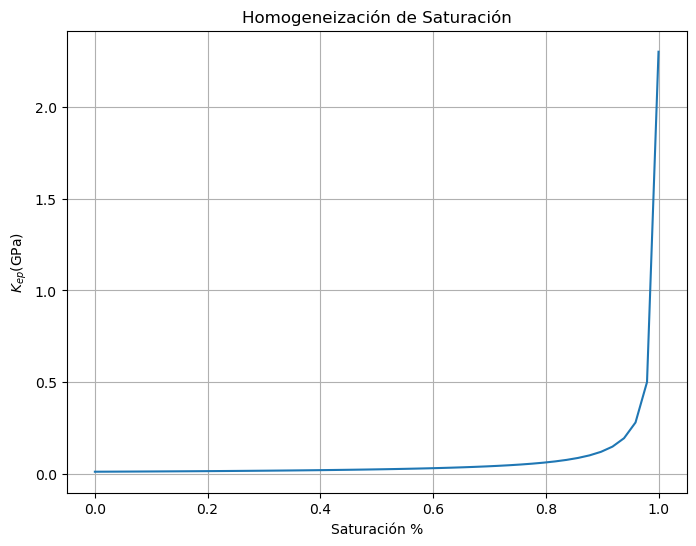

In [20]:
# Parámetros iniciales
Sat_range = np.linspace(0, 1, 50)  # Vector de saturación (de 0 a 1, 50 puntos)

# Homogeneización (vectorizada)
# Cálculo del módulo de compresibilidad efectivo en función de la saturación (Sparam)
K_ep = 1 / (Sat_range / K_w + (1 - Sat_range) / K_v)

# Gráfica
plt.figure(figsize=(8, 6))
plt.plot(Sat_range, K_ep, linewidth=1.5)
plt.grid(True)
plt.xlabel('Saturación %')  # Etiqueta del eje X
plt.ylabel(r'$K_{ep}$(GPa)')  # Etiqueta del eje Y con formato LaTeX
plt.title('Homogeneización de Saturación')  # Título de la gráfica
plt.show()

## 4.2 Módulo de compresibilidad y módulo de corte en función de la porosidad

El tensor constitutivo del compuesto $ \overline{\mathbf{C}} $ se obtiene del modelo Mori-Tanaka:

$
\overline{\mathbf{C}} = \left( (1 - \phi) \overline{\mathbf{C}}_m + \phi \left\{ \mathbf{C}_v \mathbf{A}_v^{dil} \right\} \right) : \left( (1 - \phi) \mathbf{I} + \phi \left\{ \mathbf{A}_v^{dil} \right\} \right)^{-1}
$

donde:

- $ \overline{\mathbf{C}} $ es el tensor constitutivo efectivo del compuesto.  
- $ \overline{\mathbf{C}}_m $ es el tensor constitutivo de la matriz.  
- $ \mathbf{C}_v $ es el tensor constitutivo de la inclusión (poro en este caso).  
- $ \phi $ es la fracción volumétrica de la inclusión.  
- $ \mathbf{I} $ es el tensor identidad de cuarto orden.  
- $ \mathbf{A}_v^{dil} $ es el tensor de concentración de deformaciones diluidas para inclusiones porosas, dado por:

$
\mathbf{A}_v^{dil} = \left[ \mathbf{I} + \mathbf{S}_v : \left( \overline{\mathbf{C}}_m \right)^{-1} : \left( \mathbf{C}_v - \overline{\mathbf{C}}_m \right) \right]^{-1}
$

donde:

- $ \mathbf{S}_v $ es el tensor de Eshelby del poro.  
- $ ( \overline{\mathbf{C}}_m )^{-1} $ representa la inversa del tensor constitutivo de la matriz.  
- $ (\mathbf{C}_v - \overline{\mathbf{C}}_m) $ es la diferencia entre los tensores constitutivos de la inclusión y la matriz, lo que representa el contraste de rigidez entre ambas fases.  

El modelo Mori-Tanaka permite obtener las propiedades efectivas de un material compuesto considerando la interacción entre inclusiones y matriz a través del tensor de Eshelby y la fracción volumétrica de la fase dispersa.



$
K = \frac{E}{3 (1 - 2 \nu)}
$

El módulo de compresibilidad \(K\) mide la resistencia de un material a la compresión volumétrica. Se define en función del módulo de Young \(E\) y el coeficiente de Poisson \(\nu\). Cuanto mayor sea \(K\), más difícil será comprimir el material.


$
G = \frac{E}{2 (1 + \nu)}
$

El módulo de corte \(G\), también conocido como módulo de rigidez \(G\), describe la resistencia del material a la deformación por esfuerzo cortante. Depende del módulo de Young \(E\) y del coeficiente de Poisson \(\nu\), y un valor más alto indica una mayor resistencia al corte.



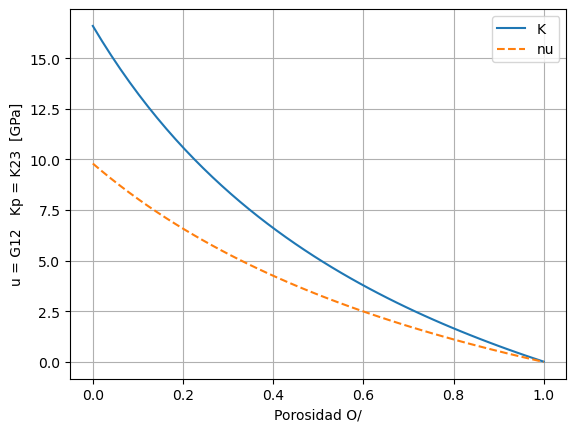

In [ ]:
I = np.eye(6)
phi = np.linspace(0, 1, 50)
K = np.zeros(len(phi))
M = np.zeros(len(phi))

for contador in range(len(phi)):
    fr = phi[contador]  # Se almacena el valor actual de phi
    fm = 1 - fr  # Se calcula el valor de fm correspondiente a phi actual
    Av = np.linalg.inv(I + S_v @ np.linalg.inv(C_m) @ (C_v - C_m))
    Bv = C_v @ Av @ np.linalg.inv(C_m)
    Ceff = (fm * C_m + (fr * Bv @ C_m)) @ np.linalg.inv((fm * I) + (fr  * Av))
    E, mu = f_compute_engineering_constants_sqrt2(Ceff)
    K[contador] = E[0] / (3 * (1 - 2 * mu[0]))
    M[contador] = E[0] / (2 * (1 + mu[0]))


# Graficar resultados
plt.figure()
plt.plot(phi, K, label='K')
plt.plot(phi, M, '--', label='nu')
plt.grid(True)
plt.ylabel('u = G12   Kp = K23  [GPa]')
plt.xlabel('Porosidad O/')
plt.legend()
plt.show()


## 4.3 Teoría sobre la Homogeneización de Materiales Porosos

Se definen los valores de saturación \( S \) y la fracción volumétrica de la fase inclusiva \( v_i \). Se consideran dos rangos de \( S \) para capturar efectos en diferentes niveles de saturación.

Para calcular el módulo de compresibilidad efectivo del poro no saturado, se utiliza la siguiente ecuación:

$K_{ep} = \frac{1}{\frac{S}{K_w} + \frac{1 - S}{K_v}}$

donde:
- \( K_w \) es el módulo de compresibilidad del agua,
- \( K_v \) es el módulo de compresibilidad del vacío.

La relación de Poisson efectiva se obtiene como:
$
\nu_p = \frac{3 - 2 \frac{G_v}{K_{ep}}}{2 (3 + \frac{G_v}{K_{ep}})}
$
donde \( G_v \) es el módulo de corte de la fase porosa.

El módulo de Young \( E_p \) se calcula como:

$E_p = 2 (1 + \mu_p) G_v$



Se define el tensor de identidad  $I_d$  y la matriz de rigidez de la matriz  $C_m$ . Posteriormente, se construyen las matrices de homogeneización:

$A = (I_d + S_E C_m^{-1} (C_p - C_m))^{-1}$


$B = C_p A C_m^{-1}$


$C_{eff} = (f_m C_m + f_r B C_m)(f_m I_d + f_r A)^{-1}$

donde \( f_m \) y \( f_r \) son las fracciones volumétricas de la matriz y la fase inclusiva, respectivamente.


Se calculan el módulo de compresibilidad \( K \) y el módulo de corte \( M \) a partir de la matriz de rigidez efectiva:

$K = \frac{E}{3(1 - 2 \nu)}$

$M = \frac{E}{2(1 + \nu)}$

donde $E$ y $\nu$ son las constantes elásticas obtenidas de $C_{eff}$ .


Se grafican los valores de \( K \) en función de \( S \) para distintas fracciones volumétricas de la fase inclusiva, permitiendo evaluar la influencia de la saturación en la respuesta mecánica del material.

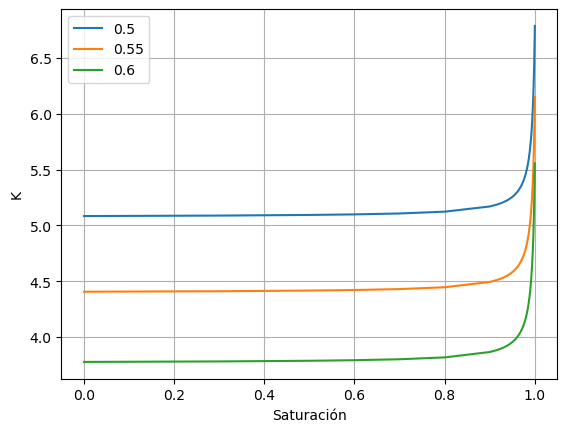

In [ ]:
# Definir parámetros
S_param = np.concatenate([np.linspace(0, 0.9, 10), np.linspace(0.91, 1, 200)])
vi_param = [0.5, 0.55, 0.6]

# Inicializar matrices de resultados
K = np.zeros((len(S_param), len(vi_param)))
M = np.zeros((len(S_param), len(vi_param)))

for contador, fr in enumerate(vi_param):
    fm = 1 - fr
    for contador2, S in enumerate(S_param):
        # Poro no saturado equivalente
        K__ep = 1 / (S / K_w + (1 - S) / K_v)
        poisp = (3 - 2 * G_v / K__ep) / (2 * (3 + G_v / K__ep))
        Ep = 2 * (1 + mu_p) * G_v
        Cp = f_isotropic(Ep, poisp)
        
        # Homogeneización
        Id = np.eye(6)
        Cm=C_m
        A = np.linalg.inv(Id + S_v @ np.linalg.inv(Cm) @ (Cp - Cm))
        B = Cp @ A @ np.linalg.inv(Cm)
        Ceff = (fm * Cm + fr * B @ Cm) @ np.linalg.inv(fm * Id + fr * A)
        
        # Cálculo de constantes 
        E, nu = f_compute_engineering_constants_sqrt2(Ceff)
        
        K[contador2, contador] = E[0] / (3 * (1 - 2 * nu[0]))
        M[contador2, contador] = E[0] / (2 * (1 + nu[0]))

# Graficar resultados
plt.figure()
for i, fr in enumerate(vi_param):
    plt.plot(S_param, K[:, i], label=f"{fr}")
plt.legend()
plt.xlabel("Saturación")
plt.ylabel("K")
plt.grid(True)
plt.show()


## 4.4

Modelo de homogeneización para materiales compuestos con inclusiones esferoidales y una capa de interfase, utilizando métodos de Eshelby y promedios orientacionales. Se enfoca en la influencia de la interfase en las propiedades elásticas efectivas del material, comparando distintos espesores de interfase y proporciones de inclusión.

### Definición de Parámetros

#### Matriz (Mortero)
La matriz es el material base del compuesto, y en este caso, se considera un material con un módulo de elasticidad de:

- **\(E_m = 23.6077\) GPa**  
- **Coeficiente de Poisson \( \nu_m = 0.2048 \)**  

A partir de estos valores, se calcula el tensor de elasticidad \( C_m \) asumiendo un comportamiento isotrópico.

#### Partículas (Agregados)
Las inclusiones representan partículas esféricas dentro de la matriz. Se definen con:

- **Módulo de elasticidad \( E_p = 80 \) GPa**
- **Coeficiente de Poisson \( \nu_p = 0.21 \)**
- **Diámetro equivalente de partícula \( D_{eq} = 450 \) μm**
- **Fracción volumétrica de las partículas \( v_p \) que varía entre 0 y 0.8**

El tensor de elasticidad \( C_p \) se obtiene bajo la hipótesis de isotropía.

#### Interfase
La interfase es una capa alrededor de cada inclusión con propiedades intermedias entre la matriz y la partícula. Sus parámetros incluyen:

- **Módulo de elasticidad \( E_i = 0.1 E_m \)**
- **Coeficiente de Poisson \( \nu_i = 0.3 \)**
- **Espesor \( t \) dependiente del diámetro de la partícula y un parámetro \( \lambda \):**
  \[
  t = \lambda D_{eq}
  \]
  Donde \( \lambda \) toma valores entre **0.0889 y 0.5**.

La respuesta mecánica de la interfase se modela mediante los métodos **Soft Interphase** (interfase blanda) o **Hard Interphase** (interfase rígida), lo que influye en la fracción volumétrica efectiva de interfase \( v_i \).

### Método de Homogeneización

Se emplea el **tensor de Eshelby**, \( S \), para modelar la deformación de las inclusiones en una matriz infinita. A partir de \( S \), se calculan los tensores de concentración \( A \) y los promedios orientacionales necesarios para obtener el módulo efectivo del compuesto.

La homogeneización se realiza mediante el modelo **Ellipsoidal Interphase Random**, que incorpora el efecto de la interfase en la rigidez efectiva \( C_{eff} \).

### Cálculo de Propiedades Efectivas

Con \( C_{eff} \), se extraen las constantes de ingeniería del material compuesto:

- **\( E_1, E_2, E_3 \): Módulos de elasticidad en distintas direcciones**
- **\( \nu \): Coeficientes de Poisson**

Se comparan dos escenarios:

1. **Con interfase**: Se usa \( C_{eff} \) del modelo con interfase.
2. **Sin interfase**: Se usa un modelo sin capa intermedia, calculado con \( C_{eff} \) de la homogenización estándar.

### Comparación con Datos Experimentales

El código incluye datos experimentales para validar los resultados. Los valores medidos del módulo de elasticidad se extraen de la literatura y corresponden a distintas fracciones volumétricas de agregado:

| \( f_p \) (Fracción volumétrica de partículas) | \( E_{exp} \) (GPa) |
|---------------------------------|------------------|
| 0.0                             | 23.6077         |
| 0.3                             | 26.350          |
| 0.4                             | 29.292          |
| 0.5                             | 32.439          |

Se ajusta un modelo basado en el método de **Levenberg-Marquardt** para minimizar la diferencia entre las predicciones teóricas y los datos experimentales. Los parámetros ajustados incluyen:

- **Relación espesor/diámetro \( t/D \)**
- **Módulo de la interfase \( E_i \)**

### Visualización de Resultados

El código genera dos figuras:

1. **Variación del módulo efectivo \( E_{eff} \) con la fracción volumétrica de inclusiones**  
   - Se comparan las predicciones teóricas con los datos experimentales.
   - Se muestra la curva ajustada del modelo.

2. **Fracción volumétrica efectiva de interfase \( v_i \) en función de \( f_p \)**  
   - Se analiza cómo varía el volumen de interfase con la fracción de partículas.




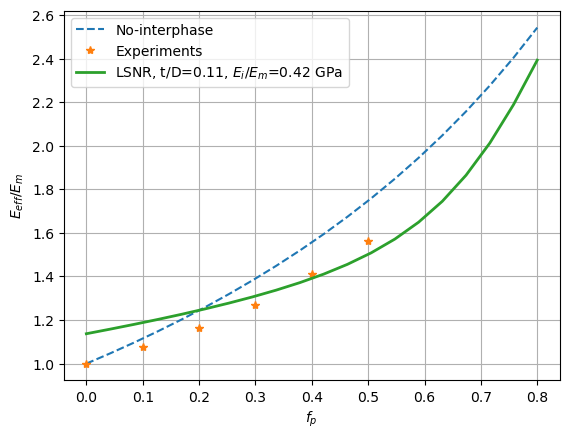

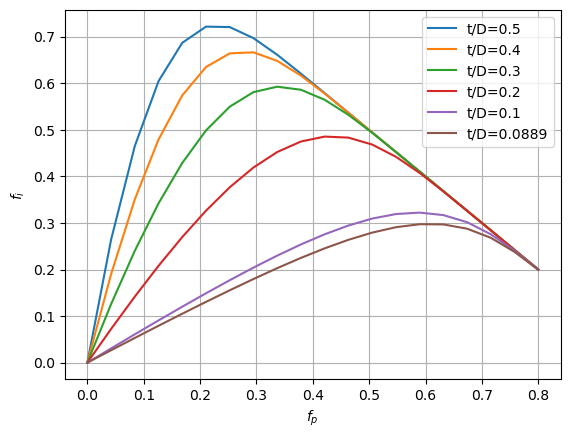

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

E_m=23.6077
mu_m=0.2048

# Parámetros iniciales
Deq = 7250  # micras

# Definición de parámetros
viparam = np.linspace(0, 0.8, 20)
lambdaparam = [0.5, 0.4, 0.3, 0.2, 0.1, 0.0889]
typeinter = 1  # 1 -> Soft, 2 -> Hard

# Inicialización de matrices de resultados
E1 = np.zeros((len(viparam), len(lambdaparam)))
E2 = np.zeros((len(viparam), len(lambdaparam)))
E3 = np.zeros((len(viparam), len(lambdaparam)))
E11 = np.zeros((len(viparam), len(lambdaparam)))
E21 = np.zeros((len(viparam), len(lambdaparam)))
E31 = np.zeros((len(viparam), len(lambdaparam)))
vicont = np.zeros((len(viparam), len(lambdaparam)))

# Bucle doble sobre los parámetros lambda y vp
for j, lambda_val in enumerate(lambdaparam):
    for i, vp in enumerate(viparam):
        Cp = f_isotropic(E_p, mu_p)
        Ei = 0.1 * E_m
        poisi = 0.3
        Kappa = 1
        t = lambda_val * Deq  # micras
        Ci = f_isotropic(Ei, poisi)
        
        Sp = f_eshelby_int([1, Kappa, 1], mu_m)
        Si = f_eshelby_int([1, Kappa, 1], mu_m)
        
        Cm=f_isotropic(E_m, mu_m)
        lambda_ratio = t / Deq
        if typeinter == 1:
            vicont[i, j] = f_softinterphase(Kappa, lambda_ratio, vp)
        else:
            vicont[i, j] = f_hardinterphase(Kappa, lambda_ratio, vp)
        
        vi = vicont[i, j]
        
        # Primera homogeneización con interfase
        Ceff = f_ellipsoidalinter_random(Cp, Ci, Cm, Si, Sp, vp, vi)
        E, nu = f_compute_engineering_constants_sqrt2(Ceff)
        
        E1[i, j] = E[0]
        E2[i, j] = E[1]
        E3[i, j] = E[2]

        # Segunda homogeneización sin interfase
        Ceff = f_ellipsoidal_nointer_random(Cp, Cm, Sp, vp)
        E, nu = f_compute_engineering_constants_sqrt2(Ceff)
        
        E11[i, j] = E[0]
        E21[i, j] = E[1]
        E31[i, j] = E[2]




# Datos experimentales
experiments = np.array([
    [0, 0.1,0.2,0.3, 0.4, 0.5],
    [20.76,22.304,24.141,26.350,29.292,32.439]
])
xdata, ydata = experiments

# Función corregida para ajuste
def fun(xdata, t_D, E_i):
    return f_MTinterparam(t_D, E_i, xdata, E_m, mu_m, E_p, mu_p, mu_i, Kappa, Deq, typeinter)

# Valores iniciales y límites

# Valores iniciales y límites
x0 = [45, 9]
bounds = ([40, 8], [50, 10])


#Ajuste de curva ###########
x, _ = curve_fit(fun, xdata, ydata, p0=x0,bounds=bounds,method='dogbox')

# Graficar resultados
plt.figure(1)
plt.plot(viparam, E11[:, -1] / E_m, '--')
plt.plot(xdata, ydata / ydata[0], '*')
plt.plot(viparam, fun(viparam, *x) / ydata[0], linewidth=2)
plt.xlabel('$f_p$')
plt.ylabel('$E_{eff}/E_m$')
plt.grid(True)
plt.legend(['No-interphase', 'Experiments', f'LSNR, t/D={x[0]/Deq:.2f}, $E_i/E_m$={x[1]/E_m:.2f} GPa'])


plt.figure(2)
for j in range(len(lambdaparam)):
    plt.plot(viparam, vicont[:, j], label=f't/D={lambdaparam[j]}')
plt.xlabel('$f_p$')
plt.ylabel('$f_i$')
plt.legend()
plt.grid(True)
plt.show()


## Modulo de Elasticidad vs Porosidad para diferentes relaciones de aspecto



### Definición de Parámetros

- **Propiedades de la matriz (concreto seco)**:
  - Módulo de Young: \(E_m = 23.6077\) GPa
  - Relación de Poisson: \(\nu_m = 0.2048\)

- **Propiedades de las inclusiones (poros saturados y secos)**:
  - **Estado seco**:
    - Módulo volumétrico: \(K_v = 0.013\) GPa
    - Módulo de corte: \(G_v = 0.00001\) GPa
  - **Estado saturado**:
    - Módulo volumétrico: \(K_w = 2.3\) GPa
    - Módulo de corte: \(G_w = 3\) GPa




1. Se emplea la solución de Eshelby para inclusiones elipsoidales con diferentes relaciones de aspecto (\(\kappa = 0.3, 0.4, 1.0\)).
2. Se calcula el tensor de concentración de esfuerzos \(S_p\) a partir de la función `eshelby_int()`.
3. Se usa la función `ellipsoidal_nointer_random()` para determinar las propiedades macroscópicas del material compuesto.


### Comparación con Datos Experimentales
- Los valores teóricos de \(E\) se comparan con los datos experimentales obtenidos de la literatura.
- Se evalúa la influencia de la porosidad y la saturación en la rigidez del material.
- Se observa que los modelos teóricos predicen adecuadamente los valores experimentales en la condición seca, pero presentan discrepancias en la condición saturada debido a la omisión de los efectos de poros capilares activos.


- Se genera una gráfica de \(E\) en función de la porosidad para los tres casos de \(\kappa\).
- Se incluyen líneas continuas para condiciones secas y líneas punteadas para condiciones saturadas.
- La gráfica muestra que los valores teóricos se ajustan bien a los datos experimentales en condiciones secas, pero hay divergencias en condiciones saturadas.


- El modelo propuesto permite estimar el módulo de Young efectivo considerando inclusiones porosas en distintos estados de saturación.
- La porosidad tiene un impacto significativo en la rigidez del material, especialmente en condiciones saturadas.
- Se sugiere mejorar el modelo incluyendo la contribución de poros capilares activos para una mejor aproximación en materiales saturados.


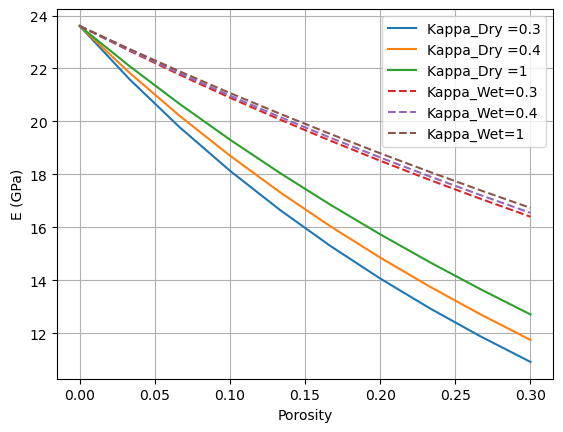

In [ ]:
viparam = np.linspace(0, 0.3, 10)
aspectparam = [0.3, 0.4, 1]

K = np.zeros((len(viparam), len(aspectparam), 2))
M = np.zeros((len(viparam), len(aspectparam), 2))
YoungMod = np.zeros((len(viparam), len(aspectparam), 2))

for satur in range(2):
    for contador2, aspect in enumerate(aspectparam):
        for contador, fr in enumerate(viparam):
            fm = 1 - fr

            # Matrix
            Em = 23.6077  # GPa
            poism = 0.2048
            Cm = f_isotropic(Em, poism)

            # Particle properties
            Gw = 3
            Kw = 2.3  # GPa
            Gv = 0.00001
            Kv = 0.013

            if satur == 0:
                S = 0
                Kp = 1 / (S / Kw + (1 - S) / Kv)
                Gp = Gv
            else:
                S = 1
                Kp = 1 / (S / Kw + (1 - S) / Kv)
                Gp = Gw

            Ep = 9 * Kp * Gp / (3 * Kp + Gp)
            poisp = (3 * Kp - 2 * Gp) / (2 * (3 * Kp + Gp))
            vp = viparam[contador]
            Cp = f_isotropic(Ep, poisp)
            Sp = f_eshelby_int([1, aspect, 1], poism)

            # Homogenization
            Ceff = f_ellipsoidal_nointer_random(Cp, Cm, Sp, fr)
            E, nu = f_compute_engineering_constants_sqrt2(Ceff)

            K[contador, contador2, satur] = E[0] / (3 * (1 - 2 * nu[0]))
            M[contador, contador2, satur] = E[0] / (2 * (1 + nu[0]))
            YoungMod[contador, contador2, satur] = E[0]

experiments = np.array([
    [0.094, 38.43], [0.102, 35.94], [0.131, 33.51], [0.129, 32.92],
    [0.128, 35.11], [0.211, 31.37], [0.161, 30.61], [0.171, 31.57],
    [0.159, 29.76], [0.155, 30.93], [0.199, 30.93], [0.17, 29.99],
    [0.207, 27.1], [0.2, 26.88], [0.208, 27.33]
])

experiments2 = np.array([
    [0.094, 40.84], [0.102, 40.78], [0.131, 38.31], [0.129, 37.36],
    [0.128, 37.47], [0.211, 36.13], [0.161, 37.04], [0.171, 36.81],
    [0.159, 37.45], [0.155, 35.75], [0.199, 33.99], [0.17, 35.46],
    [0.207, 32.86], [0.2, 33.79], [0.208, 32.18]
])

plt.figure(1)
plt.grid(True)

leyenda = []
for contador2, aspect in enumerate(aspectparam):
    plt.plot(viparam, YoungMod[:, contador2, 0], label=f'Kappa_D_r_y ={aspect}')
    leyenda.append(f'Kappa_Dry ={aspect}')

for contador2, aspect in enumerate(aspectparam):
    plt.plot(viparam, YoungMod[:, contador2, 1], '--', label=f'Kappa_W_e_t={aspect}')
    leyenda.append(f'Kappa_Wet={aspect}')

plt.xlabel('Porosity')
plt.ylabel('E (GPa)')
plt.legend(leyenda)
plt.show()


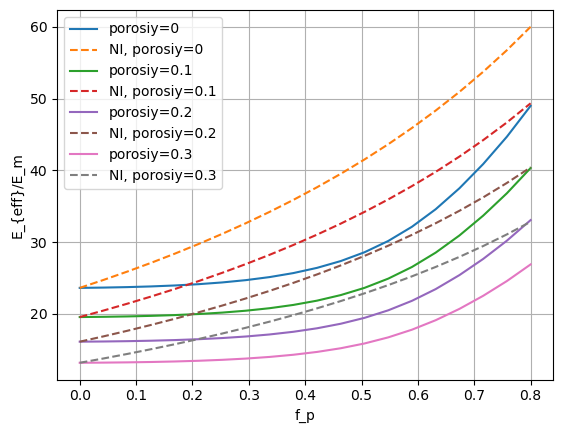

In [ ]:
# Parámetros
viparam = np.linspace(0, 0.8, 20)  #fracción de particula #DATO DE ENTRADA
porosityparam = [0, 0.1, 0.2, 0.3] #fración  de poro #DATO DE ENTRADA
typeinter = 1  # 1 -> Soft, 2 -> Hard #DATO DE ENTRADA

# Materiales
Em = 23.6077  # GPa #DATO DE ENTRADA
poism = 0.2048 #DATO DE ENTRADA
Cm = f_isotropic(Em, poism)

Ep = 80 #DATO DE ENTRADA
poisp = 0.21 #DATO DE ENTRADA
Deq = 450  # micrones #DATO DE ENTRADA
Cp = f_isotropic(Ep, poisp)

Ei = 9.4431 #DATO DE ENTRADA
poisi = 0.2048 #DATO DE ENTRADA
Kappa = 1 #DATO DE ENTRADA
t = 69  # micrones #DATO DE ENTRADA
Ci = f_isotropic(Ei, poisi)

Sp = f_eshelby_int([1, Kappa, 1], poism) #PARTICULA
Si = f_eshelby_int([1, Kappa, 1], poism) #INTERFACE

E1 = np.zeros((len(viparam), len(porosityparam)))
E2 = np.zeros((len(viparam), len(porosityparam)))
E3 = np.zeros((len(viparam), len(porosityparam)))
E11 = np.zeros((len(viparam), len(porosityparam)))
E21 = np.zeros((len(viparam), len(porosityparam)))
E31 = np.zeros((len(viparam), len(porosityparam)))

for j, fr in enumerate(porosityparam):
    for i, vp in enumerate(viparam):
        lambda_ = t / Deq
        if typeinter == 1:
            vi = f_softinterphase(Kappa, lambda_, vp)
        else:
            vi = f_hardinterphase(Kappa, lambda_, vp)
        
        # Homogeneización
        Ceff1 =f_ellipsoidalinter_random(Cp, Ci, Cm, Si, Sp, vp, vi)
        Ceff2 = f_ellipsoidal_nointer_random(Cp, Cm, Sp, vp)
        
        # Propiedades del agua y vacío
        S = 1 #DATO DE ENTRADA
        Kappavoid = 1  #DATO DE ENTRADA
        Gw = 0.00001 #DATO DE ENTRADA
        Kw = 2.3 #DATO DE ENTRADA
        Ga = 0.00001 #DATO DE ENTRADA
        Ka = 0.013 #DATO DE ENTRADA
        Kv = 1 / (S / Kw + (1 - S) / Ka)
        Gv = Ga 
        poisv = (3 - 2 * Gv / Kv) / (2 * (3 + Gv / Kv))
        Ev = 2 * (1 + poisv) * Gv
        Cv = f_isotropic(Ev, poisv)
        
        # Cálculo de constantes de ingeniería
        E, nu = f_compute_engineering_constants_sqrt2(Ceff1)
        Sebyv_inter = f_eshelby_int([1, Kappavoid, 1], nu[0])
        E, nu = f_compute_engineering_constants_sqrt2(Ceff2)
        Sebyv_nointer = f_eshelby_int([1, Kappavoid, 1], nu[0])
        
        # Homogeneización con porosidad
        Ceff = f_ellipsoidal_nointer_random(Cv, Ceff1, Sebyv_inter, fr)
        E, nu = f_compute_engineering_constants_sqrt2(Ceff)
        E1[i, j], E2[i, j], E3[i, j] = E[:3]
        
        Ceff = f_ellipsoidal_nointer_random(Cv, Ceff2, Sebyv_nointer, fr)
        E, nu = f_compute_engineering_constants_sqrt2(Ceff)
        E11[i, j], E21[i, j], E31[i, j] = E[:3]

# Gráficos
plt.figure()
for j in range(len(porosityparam)):
    plt.plot(viparam, E1[:, j], label=f'porosiy={porosityparam[j]}')
    plt.plot(viparam, E11[:, j], '--', label=f'NI, porosiy={porosityparam[j]}')

plt.xlabel('f_p')
plt.ylabel('E_{eff}/E_m')
plt.grid(True)
plt.legend()
plt.show()